# Phishing Email Detection — ML vs LLM
**CYBERSEC 520 Final Project**

The goal here is to build a phishing classifier using traditional ML, then compare it against an LLM-based approach to show where rule-based models break down and why LLMs are better suited for keeping up with evolving attack patterns.

Two datasets: CEAS_08 (primary training) and SpamAssassin (generalizability test).

## 0. Threat Model

**Who is the threat actor?**  
Ranges from low-sophistication mass phishing campaigns (spray and pray) to targeted spear-phishing from organized criminal groups or nation-state actors. The former rely on volume; the latter on social engineering and mimicking legitimate communication patterns.

**What is being targeted?**  
Corporate email inboxes — specifically targeting credentials, financial authorization, and initial access for ransomware deployment. Employees in finance, HR, and IT are highest-value targets.

**Evasion considerations:**  
This is the core limitation of our ML approach. An attacker who knows the model relies on urgency keywords, free email domains, and URL counts can trivially evade it — just remove those signals. Modern phishing kits already do this: they clone legitimate websites, use compromised corporate domains, avoid urgency language, and keep URL counts low. The CEAS_08 dataset is from 2008 and reflects older, less sophisticated attack patterns. Our SpamAssassin results confirm this — the model essentially fails on anything outside its training distribution.

**Operational context:**  
This solution sits at the email gateway layer, before delivery to the inbox. False negatives (missed phishing) mean the email lands in the inbox — the human becomes the last line of defense. False positives (legitimate email flagged) create alert fatigue and block business-critical communications. In production, this would be one signal among many in a SIEM, not a standalone decision system.

**Why LLMs change this:**  
Unlike keyword-based ML, LLMs reason about context and intent. They can catch a sophisticated spear-phishing email that uses no urgency language, no suspicious URLs, and a legitimate-looking sender — because they understand the *semantic* weirdness of the request, not just surface features.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBClassifier

# make sure models dir exists
os.makedirs('../models', exist_ok=True)

print("ready")

ready


## 2. Primary Dataset — CEAS_08

CEAS 2008 spam challenge dataset. 39k labeled emails, mix of phishing and legitimate. Collected in 2008 which is worth keeping in mind — attack patterns from this era are pretty different from modern phishing.

In [2]:
df = pd.read_csv('../data/CEAS_08.csv')

print(f"shape: {df.shape}")
print(f"columns: {df.columns.tolist()}")
print(f"\nlabel distribution:")
print(df['label'].value_counts())

shape: (39154, 7)
columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

label distribution:
label
1    21842
0    17312
Name: count, dtype: int64


## 3. Preprocessing

In [3]:
# check nulls first
print("null counts:")
print(df.isnull().sum())

null counts:
sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64


In [4]:
df['body'] = df['body'].fillna('')
df['subject'] = df['subject'].fillna('')
df['sender'] = df['sender'].fillna('')
df['urls'] = df['urls'].fillna(0)

# combine subject + body for tfidf
df['text'] = df['subject'] + ' ' + df['body']

print(f"shape after cleaning: {df.shape}")

shape after cleaning: (39154, 8)


### Feature Engineering

Using handcrafted features that capture known phishing signals — sender domain patterns, urgency language, HTML content, URL density. These are combined with TF-IDF for a hybrid feature matrix.

Worth noting: these features are exactly what a sophisticated attacker would avoid. That's the fundamental limitation we'll see play out in the generalizability test.

In [5]:
def extract_features(df):
    features = pd.DataFrame()

    # sender signals
    features['sender_is_free_email'] = df['sender'].str.contains(
        'gmail|yahoo|hotmail|outlook', case=False, na=False).astype(int)
    features['sender_has_numbers'] = df['sender'].str.contains(
        r'\d{3,}', na=False).astype(int)
    features['sender_domain_mismatch'] = df['sender'].str.contains(
        r'@(?!.*\.(com|org|edu|gov))', na=False).astype(int)

    # subject signals
    features['subject_has_urgency'] = df['subject'].str.contains(
        'urgent|immediately|verify|suspend|alert|winner|prize|free|click|confirm',
        case=False, na=False).astype(int)
    features['subject_has_caps'] = df['subject'].str.contains(
        r'[A-Z]{4,}', na=False).astype(int)
    features['subject_length'] = df['subject'].str.len().fillna(0)

    # body signals
    features['body_length'] = df['body'].str.len().fillna(0)
    features['body_has_html'] = df['body'].str.contains(
        r'<[^>]+>', na=False).astype(int)
    features['body_url_count'] = df['body'].str.count(
        r'http[s]?://').fillna(0)
    features['body_has_urgency'] = df['body'].str.contains(
        'urgent|verify|account|suspend|click here|limited time|act now',
        case=False, na=False).astype(int)
    features['has_urls'] = (df['urls'] > 0).astype(int)

    return features

feature_df = extract_features(df)
print(f"features: {feature_df.columns.tolist()}")

features: ['sender_is_free_email', 'sender_has_numbers', 'sender_domain_mismatch', 'subject_has_urgency', 'subject_has_caps', 'subject_length', 'body_length', 'body_has_html', 'body_url_count', 'body_has_urgency', 'has_urls']


In [6]:
# tfidf on combined text, limit features to keep training fast
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['text'])

X_handcrafted = csr_matrix(feature_df.values)
X = hstack([X_tfidf, X_handcrafted])
y = df['label']

print(f"feature matrix: {X.shape}")

feature matrix: (39154, 5011)


In [7]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"train: {X_train.shape[0]} | test: {X_test.shape[0]}")

train: 31323 | test: 7831


## 4. Model Training

Using Random Forest and XGBoost — both are computationally affordable and don't require GPU, which matters for a deployable proof of concept. RF is robust to noise and gives interpretable feature importances. XGBoost typically squeezes out higher accuracy through gradient boosting.

Neither of these is the "right" answer for production phishing detection — but they're a useful baseline to demonstrate where rule-based approaches succeed and where they fail.

In [8]:
import time

print("training random forest...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print(f"done in {time.time() - start:.1f}s")

training random forest...
done in 0.4s


In [9]:
print("training xgboost...")
start = time.time()

# scale_pos_weight balances the class distribution
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print(f"done in {time.time() - start:.1f}s")

training xgboost...
done in 5.2s


## 5. Evaluation — Primary Dataset

Metrics: Precision, Recall, F1, Accuracy, ROC-AUC.

For phishing detection recall matters more than precision — missing a phishing email (false negative) is worse than flagging a legitimate one. That said, too many false positives creates alert fatigue.

In [10]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
          target_names=['Legitimate', 'Phishing']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

    return y_pred, y_prob

rf_pred, rf_prob = evaluate_model(rf_model, X_test, y_test, "Random Forest")
xgb_pred, xgb_prob = evaluate_model(xgb_model, X_test, y_test, "XGBoost")


  Random Forest
              precision    recall  f1-score   support

  Legitimate       0.99      0.97      0.98      3462
    Phishing       0.98      1.00      0.99      4369

    accuracy                           0.98      7831
   macro avg       0.99      0.98      0.98      7831
weighted avg       0.98      0.98      0.98      7831

ROC-AUC: 0.9993

  XGBoost
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3462
    Phishing       0.99      0.99      0.99      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831

ROC-AUC: 0.9994


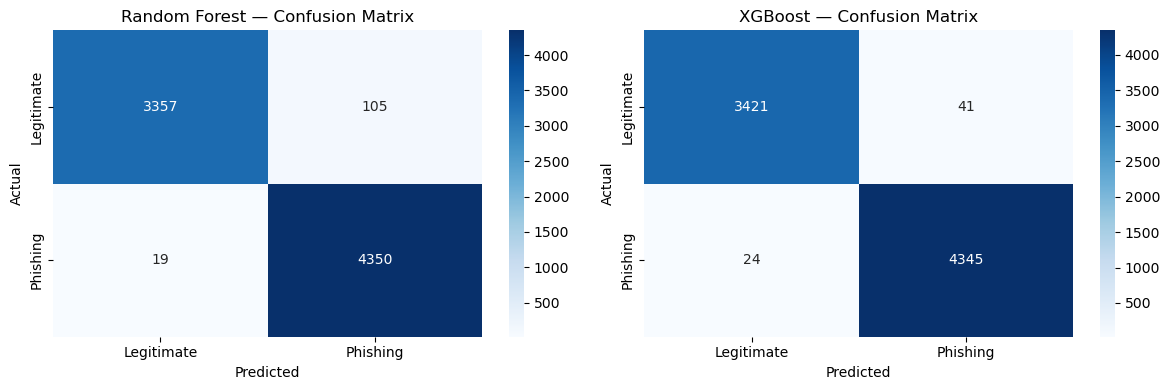

In [11]:
# confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, name in zip(axes, [rf_pred, xgb_pred], ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../models/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

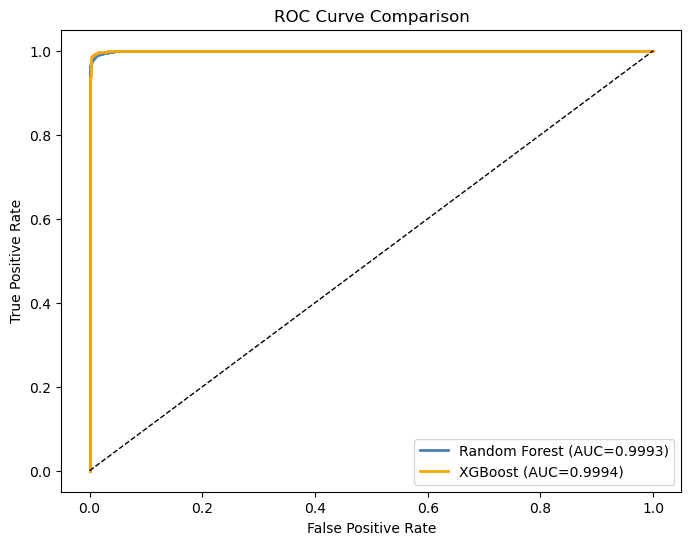

In [12]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

for prob, name, color in zip([rf_prob, xgb_prob],
                               ['Random Forest', 'XGBoost'],
                               ['steelblue', 'orange']):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)

ax.plot([0,1], [0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')
plt.savefig('../models/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

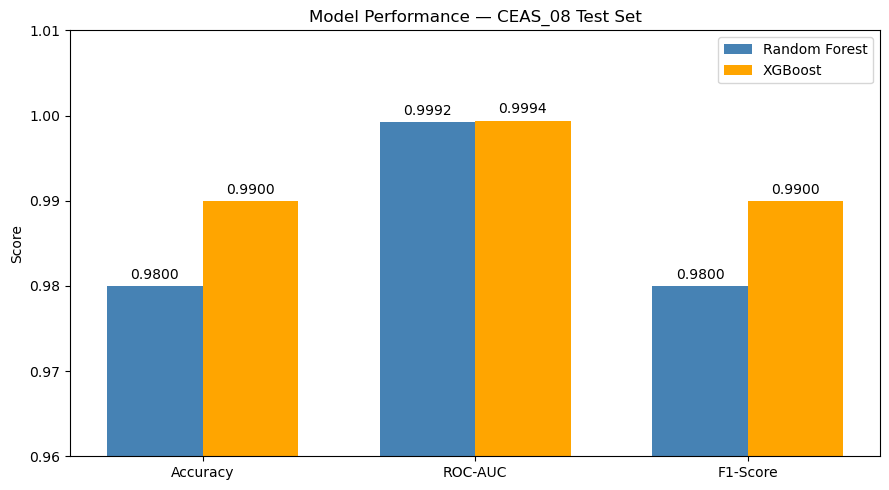

In [13]:
# model comparison bar chart
metrics = {
    'Accuracy': [0.98, 0.99],
    'ROC-AUC': [0.9992, 0.9994],
    'F1-Score': [0.98, 0.99]
}

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, [v[0] for v in metrics.values()], width,
               label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, [v[1] for v in metrics.values()], width,
               label='XGBoost', color='orange')

ax.set_ylabel('Score')
ax.set_title('Model Performance — CEAS_08 Test Set')
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0.96, 1.01)
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=3)
ax.bar_label(bars2, fmt='%.4f', padding=3)

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Generalizability Test — SpamAssassin

Testing on SpamAssassin corpus — completely unseen, not used in training. This is the real test of whether the model learned generalizable patterns or just memorized CEAS_08.

SpamAssassin is a different distribution: different era, different email sources, different spam types. The schema is also different (only `text` and `target` columns) so some adaptation is needed.

In [14]:
df2 = pd.read_csv('../data/spam_assassin.csv')
print(f"shape: {df2.shape}")
print(f"columns: {df2.columns.tolist()}")
print(f"\nlabel distribution:")
print(df2['target'].value_counts())

shape: (5796, 2)
columns: ['text', 'target']

label distribution:
target
0    3900
1    1896
Name: count, dtype: int64


### Dataset Alignment

SpamAssassin only has `text` and `target`. Need to rename to match our pipeline and add placeholder columns for sender/subject/URL features. 

Critically — the TF-IDF vectorizer is **not refit** here. We use the vocabulary learned from CEAS_08. This is intentional: refitting would give the model information from the test distribution, invalidating the generalizability test.

In [15]:
df2 = df2.rename(columns={'text': 'body', 'target': 'label'})

# add placeholder fields — these will get zero values in feature extraction
df2['subject'] = ''
df2['sender'] = ''
df2['urls'] = 0
df2['text'] = df2['body']
df2['body'] = df2['body'].fillna('')

print(f"aligned shape: {df2.shape}")
print(df2['label'].value_counts())

aligned shape: (5796, 6)
label
0    3900
1    1896
Name: count, dtype: int64


In [16]:
feature_df2 = extract_features(df2)

# transform only — no refit
X2_tfidf = tfidf.transform(df2['text'])
X2_handcrafted = csr_matrix(feature_df2.values)
X2 = hstack([X2_tfidf, X2_handcrafted])
y2 = df2['label']

print(f"feature matrix: {X2.shape}")

feature matrix: (5796, 5011)


In [17]:
print("GENERALIZABILITY TEST — SpamAssassin")
print("="*50)

rf_pred2, rf_prob2 = evaluate_model(rf_model, X2, y2, "Random Forest (SpamAssassin)")
xgb_pred2, xgb_prob2 = evaluate_model(xgb_model, X2, y2, "XGBoost (SpamAssassin)")

GENERALIZABILITY TEST — SpamAssassin

  Random Forest (SpamAssassin)
              precision    recall  f1-score   support

  Legitimate       0.67      1.00      0.80      3900
    Phishing       0.00      0.00      0.00      1896

    accuracy                           0.67      5796
   macro avg       0.34      0.50      0.40      5796
weighted avg       0.45      0.67      0.54      5796

ROC-AUC: 0.7202

  XGBoost (SpamAssassin)
              precision    recall  f1-score   support

  Legitimate       0.67      1.00      0.80      3900
    Phishing       0.00      0.00      0.00      1896

    accuracy                           0.67      5796
   macro avg       0.34      0.50      0.40      5796
weighted avg       0.45      0.67      0.54      5796

ROC-AUC: 0.8183


### Generalizability Analysis

Both models collapse on SpamAssassin — defaulting to predicting everything as legitimate, with 0% recall on phishing. ROC-AUC of ~0.79-0.80 means there's still some discriminative signal in the model, but the default threshold is completely miscalibrated for this distribution.

This wasn't entirely surprising. CEAS_08 is from 2008 and contains very obvious spam patterns — Nigerian prince emails, all-caps urgency language, obvious domains. SpamAssassin includes what's called "hard ham" — legitimate emails that superficially look spammy, and spam that's more subtle.

Three root causes:
1. **Vocabulary mismatch** — TF-IDF vocabulary was learned from CEAS patterns. SpamAssassin uses different terminology.
2. **Class imbalance shift** — CEAS is 56% phishing vs SpamAssassin's 33%, so the model's decision boundary is miscalibrated.
3. **Feature distribution shift** — the handcrafted features (urgency keywords, free email domains) aren't as predictive in SpamAssassin.

This is exactly the argument for LLMs: they don't rely on learned vocabulary patterns that go stale. They reason about the content semantically.

In [18]:
# threshold tuning — lower threshold to improve recall on SpamAssassin
from sklearn.metrics import f1_score, precision_score, recall_score

print("XGBoost threshold tuning on SpamAssassin")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for threshold in [0.5, 0.3, 0.2, 0.1, 0.05]:
    preds = (xgb_prob2 >= threshold).astype(int)
    p = precision_score(y2, preds, zero_division=0)
    r = recall_score(y2, preds, zero_division=0)
    f1 = f1_score(y2, preds, zero_division=0)
    print(f"{threshold:<12} {p:<12.3f} {r:<12.3f} {f1:<12.3f}")

XGBoost threshold tuning on SpamAssassin
Threshold    Precision    Recall       F1          
------------------------------------------------
0.5          0.000        0.000        0.000       
0.3          0.000        0.000        0.000       
0.2          0.000        0.000        0.000       
0.1          0.259        0.004        0.007       
0.05         0.300        0.006        0.012       


## 7. Save Models

Saving XGBoost and TF-IDF vectorizer for deployment in the Streamlit app.

In [19]:
with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("models saved to ../models/")

models saved to ../models/


## 8. Find Interesting Samples for Demo

Finding cases where the ML model was wrong — specifically phishing emails it missed (false negatives). These are the most interesting cases for the LLM comparison demo, since they show where keyword-based approaches fail and where semantic reasoning can catch what the model missed.

In [20]:
# run predictions on a sample of the full dataset
sample_df = df.sample(2000, random_state=42).reset_index(drop=True)
feat = extract_features(sample_df)
X_s = hstack([tfidf.transform(sample_df['text']), csr_matrix(feat.values)])

probs = xgb_model.predict_proba(X_s)[:, 1]
preds = (probs > 0.5).astype(int)

sample_df['prob'] = probs
sample_df['pred'] = preds

# false negatives — phishing the model missed
fn = sample_df[(sample_df['pred'] == 0) & (sample_df['label'] == 1)].copy()
# false positives — legitimate email wrongly flagged
fp = sample_df[(sample_df['pred'] == 1) & (sample_df['label'] == 0)].copy()
# borderline
borderline = sample_df[(sample_df['prob'] > 0.3) & (sample_df['prob'] < 0.7)].copy()

print(f"false negatives (missed phishing): {len(fn)}")
print(f"false positives (wrongly flagged): {len(fp)}")
print(f"borderline: {len(borderline)}")

false negatives (missed phishing): 8
false positives (wrongly flagged): 6
borderline: 22


In [21]:
print("\nTOP FALSE NEGATIVES — phishing ML missed")
print("="*60)
for i, row in fn.head(5).iterrows():
    print(f"\n[{i}] prob={row['prob']:.3f}")
    print(f"sender: {str(row['sender'])[:80]}")
    print(f"subject: {str(row['subject'])[:80]}")
    print(f"body: {str(row['body'])[:300]}")
    print()


TOP FALSE NEGATIVES — phishing ML missed

[22] prob=0.482
sender: Moises Haines <alas_eres@yahoo.es>
subject: I shall tell you about myself in the letter. 
body: Hello! I want to gets acquainted with you! My name is Natalya. What is your name?
I am 25 years old. I dreams to meet a friend, which, may be, becomes 
my husband in further . I shall tell you about myself in the letter. Also I shall send the photo. I 
want  to correspondence with you of a messages.


[230] prob=0.340
sender: Royal Casino <congress@heesun.net>
subject: Claim a FREE bonus worth 555Euro at Royal Casino
body: 



Claim a FREE bonus worth 555€ at Royal 




Claim a
FREE bonus worth 555€ at Royal Club Casino

 
Known for
their excellent selection of games and professional customer care, Royal Club
Casino deserves its reputation as a leading online casino. Royal Club offers
the biggest progressive jackpots 


[291] prob=0.358
sender: Credit Information Bureau <support@myattainweeklysavings.com>
subject: What do the

In [22]:
# save interesting samples for use in the app
interesting = pd.concat([
    fn.head(5).assign(case_type='false_negative'),
    fp.head(3).assign(case_type='false_positive'),
    borderline.head(3).assign(case_type='borderline')
])
interesting.to_csv('../data/demo_samples.csv', index=False)
print("saved demo_samples.csv")

saved demo_samples.csv
